In [ ]:
!pip install scorecardpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60629 sha256=beaf003aa0e43b0889b6c4ee3cd807c251c1a71caf6dfed29c37bc246b5b3091
  Stored in directory: /root/.cache/pip/wheels/9f/d8/4e/61a6f4e78fe6700f66b699ab38377f0aa5b33e3ef55751ba38
Successfully built scorecardpy


In [ ]:
import pandas as pd
import numpy as np
import scorecardpy as sc

pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('/content/cleaned_application_train.csv')

In [ ]:
#removing the id columns
drop_cols = ['SK_ID_CURR']

df.drop(columns=drop_cols, inplace=True)

In [ ]:
#train-test split
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['TARGET']
)

In [ ]:
# STEP 5 — Variable Filtering

# This removes:

# low information variables
# highly missing variables
# identical variables

dt_s = sc.var_filter(
    train,
    y='TARGET'
)

[INFO] filtering variables ...
Variable filtering on 16204 rows and 109 columns in 00:01:20 
41 variables are removed


In [ ]:
#WOE binning
bins = sc.woebin(
    dt_s,
    y='TARGET'
)

/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is

[INFO] creating woe binning ...
>>> There are 1 variables have too many unique non-numberic values, which might cause the binning process slow. Please double check the following variables: 
ORGANIZATION_TYPE
>>> Continue the binning process?
1: yes 
2: no
Selection: 1


/usr/local/lib/python3.12/dist-packages/scorecardpy/woebin.py:320: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  init_bin = dtm.groupby('bin', group_keys=False)['y'].agg([n0, n1])\
/usr/local/lib/python3.12/dist-packages/scorecardpy/woebin.py:160: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['[0.13,0.14)', '[0.13,0.14)', '[0.13,0.14)', '[0.14,0.15000000000000002)', '[0.1,0.11000000000000001)', ..., '[0.13,0.14)', '[0.13,0.14)', '[0.03,0.04)', '[0.20000000000000004,0.21000000000000005)', '[0.3400000000000001,0.3500000000000001)']
Length: 16204
Categories (38, object): ['[-inf,0.03)' < '[0.03,0.04)' < '[0.04,0.05)' <
                          '[0.05,0.060000000000000005)' ... '[0.3700000000000001,0.3800000000000001)' <
       

Binning on 16204 rows and 68 columns in 00:00:53


In [ ]:
#iv values
iv_df = sc.iv(
    dt_s,
    y='TARGET'
)

iv_df.head(20)

,variable,info_value
19,EXT_SOURCE_1,1.005593
63,AMT_CREDIT,0.933483
57,CREDIT_INCOME_RATIO,0.851355
60,AMT_ANNUITY,0.848692
20,CREDIT_TERM,0.845162
24,EXT_SOURCE_3,0.736024
62,NONLIVINGAREA_MODE,0.710679
43,NONLIVINGAREA_MEDI,0.700686
47,LIVINGAREA_AVG,0.697143
23,LIVINGAREA_MODE,0.695898


{'EXT_SOURCE_3': <Figure size 640x480 with 2 Axes>}

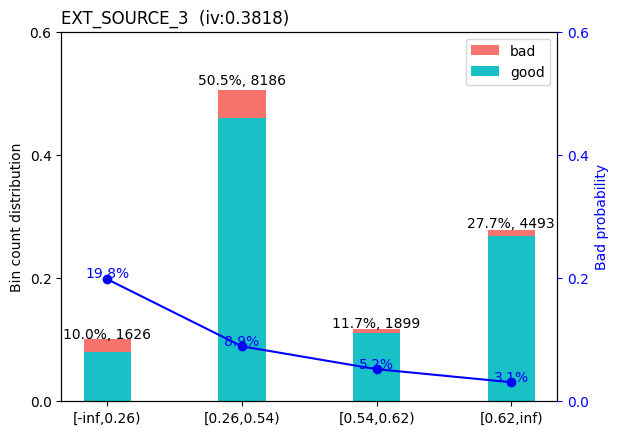

In [ ]:
sc.woebin_plot(bins['EXT_SOURCE_3'])

{'CREDIT_INCOME_RATIO': <Figure size 640x480 with 2 Axes>}

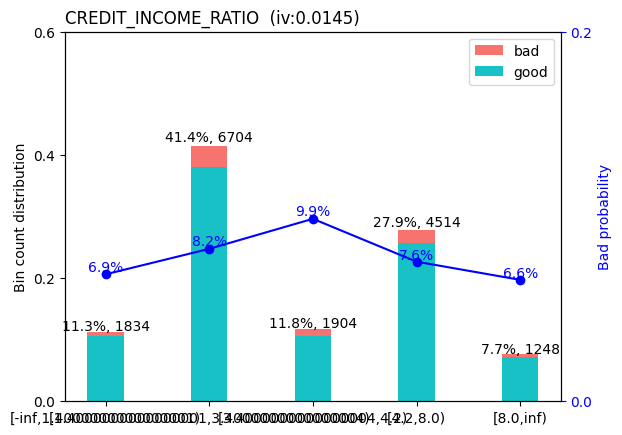

In [ ]:
sc.woebin_plot(bins['CREDIT_INCOME_RATIO'])

In [ ]:
#convert in WOE values
train_woe = sc.woebin_ply(
    train,
    bins
)

test_woe = sc.woebin_ply(
    test,
    bins
)

[INFO] converting into woe values ...
[INFO] converting into woe values ...


In [ ]:
train_woe.head()

,REG_REGION_NOT_LIVE_REGION,NAME_TYPE_SUITE,AMT_REQ_CREDIT_BUREAU_DAY,FLAG_DOCUMENT_19,FLAG_DOCUMENT_7,FLAG_WORK_PHONE,REG_REGION_NOT_WORK_REGION,FLAG_MOBIL,FLAG_DOCUMENT_6,OBS_30_CNT_SOCIAL_CIRCLE,AMT_REQ_CREDIT_BUREAU_MON,LIVE_REGION_NOT_WORK_REGION,AMT_REQ_CREDIT_BUREAU_WEEK,OBS_60_CNT_SOCIAL_CIRCLE,FLAG_DOCUMENT_4,FLAG_DOCUMENT_12,FLAG_DOCUMENT_5,WEEKDAY_APPR_PROCESS_START,FLAG_DOCUMENT_21,FLAG_PHONE,FLAG_DOCUMENT_13,FLAG_DOCUMENT_18,FLAG_DOCUMENT_17,DEF_30_CNT_SOCIAL_CIRCLE,FLAG_DOCUMENT_20,FLAG_DOCUMENT_10,FLAG_OWN_CAR,FLAG_DOCUMENT_16,AMT_REQ_CREDIT_BUREAU_HOUR,FLAG_DOCUMENT_9,FLAG_DOCUMENT_8,FLAG_DOCUMENT_15,FLAG_DOCUMENT_2,FLAG_CONT_MOBILE,TARGET,FLAG_DOCUMENT_14,FLAG_EMAIL,AMT_REQ_CREDIT_BUREAU_QRT,DEF_60_CNT_SOCIAL_CIRCLE,LIVE_CITY_NOT_WORK_CITY,FLAG_DOCUMENT_11,FLAG_OWN_REALTY,APARTMENTS_MEDI_woe,ENTRANCES_AVG_woe,CNT_CHILDREN_woe,CNT_FAM_MEMBERS_woe,ANNUITY_INCOME_RATIO_woe,DAYS_ID_PUBLISH_woe,CODE_GENDER_woe,REG_CITY_NOT_WORK_CITY_woe,FLOORSMAX_AVG_woe,YEARS_BEGINEXPLUATATION_MODE_woe,NAME_FAMILY_STATUS_woe,REG_CITY_NOT_LIVE_CITY_woe,DAYS_BIRTH_woe,BASEMENTAREA_MODE_woe,ELEVATORS_AVG_woe,FLOORSMAX_MODE_woe,LANDAREA_AVG_woe,NONLIVINGAREA_MEDI_woe,LIVINGAREA_MEDI_woe,WALLSMATERIAL_MODE_woe,AMT_INCOME_TOTAL_woe,NAME_INCOME_TYPE_woe,FLAG_DOCUMENT_3_woe,LIVINGAREA_AVG_woe,FLAG_EMP_PHONE_woe,YEARS_BEGINEXPLUATATION_MEDI_woe,LANDAREA_MEDI_woe,ELEVATORS_MODE_woe,EMERGENCYSTATE_MODE_woe,OCCUPATION_TYPE_woe,NONLIVINGAREA_AVG_woe,NAME_EDUCATION_TYPE_woe,FLOORSMAX_MEDI_woe,DAYS_EMPLOYED_woe,HOUSETYPE_MODE_woe,AMT_REQ_CREDIT_BUREAU_YEAR_woe,YEARS_BEGINEXPLUATATION_AVG_woe,BASEMENTAREA_AVG_woe,DAYS_LAST_PHONE_CHANGE_woe,EXT_SOURCE_1_woe,AGE_YEARS_woe,CREDIT_TERM_woe,ORGANIZATION_TYPE_woe,CREDIT_INCOME_RATIO_woe,ENTRANCES_MEDI_woe,NAME_HOUSING_TYPE_woe,BASEMENTAREA_MEDI_woe,NAME_CONTRACT_TYPE_woe,LIVINGAREA_MODE_woe,EXT_SOURCE_3_woe,AMT_ANNUITY_woe,APARTMENTS_MODE_woe,REGION_RATING_CLIENT_woe,LANDAREA_MODE_woe,EMPLOYMENT_YEARS_woe,ENTRANCES_MODE_woe,NONLIVINGAREA_MODE_woe,TOTALAREA_MODE_woe,APARTMENTS_AVG_woe,AMT_CREDIT_woe,HOUR_APPR_PROCESS_START_woe,DAYS_REGISTRATION_woe,REGION_POPULATION_RELATIVE_woe,EXT_SOURCE_2_woe,ELEVATORS_MEDI_woe,AMT_GOODS_PRICE_woe,REGION_RATING_CLIENT_W_CITY_woe
14121,0,Unaccompanied,0.0,0,0,0,0,1,0,0.0,0.0,0,0.0,0.0,0,0,0,WEDNESDAY,0,0,0,0,0,0.0,0,0,Y,0,0.0,0,0,0,0,1,0,0,0,2.0,0.0,0,0,Y,0.098701,0.074053,-0.09325,-0.128566,-0.113476,0.048434,-0.158466,-0.097938,0.055866,0.127066,-0.082929,-0.048647,-0.14944,0.078784,0.054632,0.059344,0.077858,0.013180,0.124031,0.135930,0.091919,0.190738,0.108283,0.128768,0.065825,0.130516,0.081064,0.048153,0.148069,0.138734,0.028268,-0.508874,0.055388,0.319050,0.133345,-0.153334,0.130665,0.081122,0.121786,0.046342,-0.145438,-0.229231,0.185170,-0.056850,0.074760,-0.039533,0.093863,0.050135,0.128227,-0.452764,0.080685,0.090599,-0.014441,0.079968,0.308831,0.044764,0.018877,0.130501,0.122588,-0.042189,0.006434,-0.415408,0.007729,0.641267,0.063023,-0.083510,-0.014908
4610,0,Family,0.0,0,0,0,0,1,0,0.0,0.0,0,0.0,0.0,0,0,0,TUESDAY,0,1,0,0,0,0.0,0,0,Y,0,0.0,0,0,0,0,1,0,0,0,0.0,0.0,0,0,Y,0.098701,0.074053,-0.09325,-0.128566,-0.113476,-0.285006,0.255224,-0.097938,0.055866,0.127066,-0.082929,-0.048647,-0.49203,0.078784,0.054632,0.059344,0.077858,0.013180,0.124031,0.135930,0.091919,-0.357526,0.108283,0.128768,-0.358619,0.130516,0.081064,0.048153,0.148069,-0.185270,0.028268,0.128980,0.055388,-0.358255,0.133345,-0.153334,0.130665,0.081122,-0.294390,-0.563767,-0.485284,0.629581,-0.310402,0.038646,0.074760,-0.039533,0.093863,0.050135,0.128227,0.123928,0.080685,0.090599,-0.014441,0.079968,-0.424493,0.044764,0.018877,0.130501,0.122588,0.245427,0.006434,0.134545,0.007729,-0.151339,0.063023,0.272689,-0.014908
2303,0,Unaccompanied,0.0,0,0,0,0,1,0,4.0,0.0,0,0.0,4.0,0,0,0,THURSDAY,0,0,0,0,0,0.0,0,0,Y,0,0.0,0,0,0,0,1,0,0,0,0.0,0.0,0,0,Y,0.098701,0.074053,-0.09325,-0.128566,-0.113476,0.048434,0.255224,-0.097938,0.055866,0.127066,-0.082929,-0.048647,-0.14944,0.078784,0.054632,0.059344,0.07785

In [ ]:
train_woe.to_csv('/content/train_woe.csv', index=False)

test_woe.to_csv('/content/test_woe.csv', index=False)

In [ ]:
from google.colab import files
files.download('/content/train_woe.csv')
files.download('/content/test_woe.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>